# 02 - Exploratory Data Analysis (EDA)

## Objetivo

O objetivo desta etapa é explorar os dados para compreender padrões, tendências e possíveis fatores que influenciam a demanda dos produtos.

As análises realizadas nesta fase servirão de apoio para a Engenharia de Atributos e para a construção dos modelos de previsão.

## Informações da Etapa

**Fase do Projeto:** Exploratory Data Analysis (CRISP-DM)

**Objetivo da Etapa:** Explorar os dados, identificar padrões e levantar hipóteses que possam contribuir para o desenvolvimento do modelo de previsão.

**Entregável Esperado:** Relatório exploratório contendo estatísticas descritivas, visualizações e principais insights encontrados.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [36]:
sales = pd.read_csv("../data/raw/sales_train_validation.csv")
calendar = pd.read_csv("../data/raw/calendar.csv")
prices = pd.read_csv("../data/raw/sell_prices.csv")

## Objetivo

Existem produtos que nunca venderam durante todo o período analisado?

### Hipótese

É possível que existam produtos sem nenhuma venda registrada durante todo o período da base.

In [37]:
# Seleciona apenas as colunas de vendas
sales_by_day = sales.filter(regex="^d_")

# Soma todas as vendas de cada produto
product_total_sales = sales_by_day.sum(axis=1)

# Identifica produtos sem vendas
products_without_sales = product_total_sales == 0

# Quantidade de produtos sem vendas
number_of_products_without_sales = products_without_sales.sum()

In [38]:
## Conclusão

print(
    f"Foram encontrados {number_of_products_without_sales} "
    f"produtos sem vendas durante todo o período analisado."
)

Foram encontrados 0 produtos sem vendas durante todo o período analisado.


## Objetivo

Quais produtos apresentaram o maior volume de vendas durante todo o período analisado?

### Hipótese

Espera-se que uma pequena parcela dos produtos concentre grande parte do volume total de vendas.

In [39]:
# Cria um DataFrame contendo o identificador do produto e o total de vendas
top_products = pd.DataFrame(
    {"item_id": sales["item_id"], "total_sales": product_total_sales}
)

# Ordena os produtos pelo total de vendas
top_products = top_products.sort_values(by="total_sales", ascending=False)

# Exibe os 10 produtos mais vendidos
top_products.head(10)

,item_id,total_sales
8412,FOODS_3_090,250502
18055,FOODS_3_586,192835
21104,FOODS_3_586,150122
8908,FOODS_3_586,134386
2314,FOODS_3_090,127203
29755,FOODS_3_090,121434
17559,FOODS_3_090,119496
20608,FOODS_3_090,114854
17721,FOODS_3_252,114153
15006,FOODS_3_586,112454


### Resultado

Foram identificados os 10 produtos com maior volume de vendas durante todo o período analisado.

### Interpretação

Observa-se que alguns produtos apresentam um volume de vendas significativamente superior aos demais, indicando concentração da demanda em determinados itens.

### Insight para a Modelagem

Produtos com elevada demanda poderão apresentar comportamento distinto dos demais e merecem atenção durante a construção e avaliação dos modelos preditivos.

## Objetivo


Como está distribuído o volume de vendas entre os produtos?

### Hipótese

Espera-se que poucos produtos concentrem grande parte das vendas, enquanto a maioria apresente menor volume comercializado.

In [40]:
# Estatísticas descritivas do total de vendas
top_products["total_sales"].describe()

count     30490.000000
mean       2154.654280
std        5217.226438
min          10.000000
25%         355.000000
50%         848.000000
75%        2031.750000
max      250502.000000
Name: total_sales, dtype: float64

## Objetivo

Como está distribuído o volume total de vendas entre os produtos?

### Hipótese

Espera-se que a distribuição seja assimétrica, com poucos produtos apresentando elevado volume de vendas e a maioria concentrando baixos volumes.

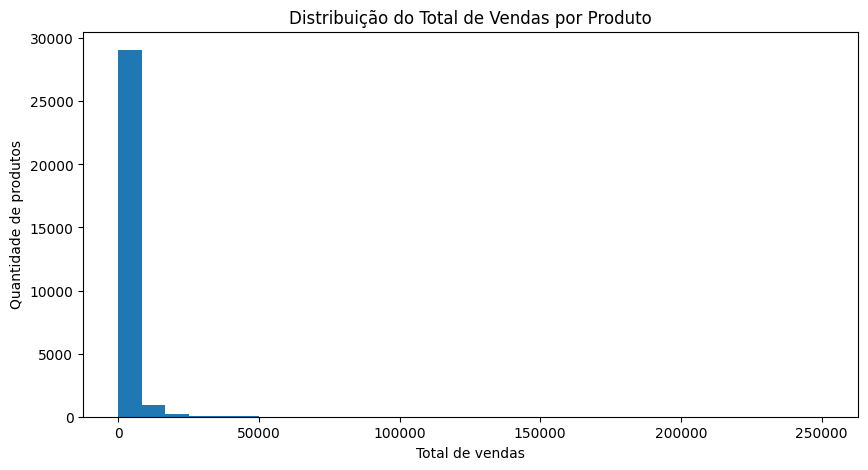

In [41]:
plt.figure(figsize=(10, 5))

plt.hist(top_products["total_sales"], bins=30)

plt.title("Distribuição do Total de Vendas por Produto")
plt.xlabel("Total de vendas")
plt.ylabel("Quantidade de produtos")

plt.show()

### Resultado

O histograma evidencia que a maior parte dos produtos apresenta baixo volume total de vendas, enquanto um número reduzido de produtos concentra volumes significativamente mais elevados.

### Interpretação

A distribuição é assimétrica à direita (assimetria positiva), indicando que a maioria dos produtos possui vendas relativamente baixas e poucos produtos apresentam vendas excepcionalmente altas. Esse comportamento é comum em cenários de varejo, nos quais alguns itens concentram grande parte da demanda.

### Insight para a Modelagem

A presença de uma distribuição assimétrica sugere que o modelo de previsão deverá capturar diferentes padrões de demanda entre os produtos. Além disso, será importante investigar a existência de valores extremos (outliers) e avaliar seu impacto durante a etapa de modelagem.

## Objetivo

Existem produtos com volume de vendas muito acima do comportamento da maioria dos produtos?

### Hipótese

Espera-se identificar produtos com volume de vendas significativamente superior ao restante da base, caracterizando a presença de valores extremos (outliers).

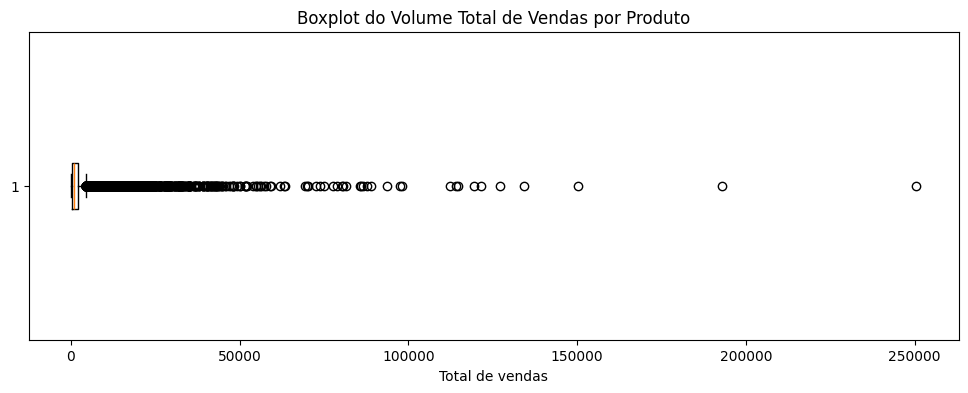

In [42]:
plt.figure(figsize=(12, 4))

plt.boxplot(top_products["total_sales"], vert=False)

plt.title("Boxplot do Volume Total de Vendas por Produto")
plt.xlabel("Total de vendas")

plt.show()

### Resultado

O boxplot evidencia a presença de diversos valores extremos (outliers) no volume total de vendas dos produtos.

### Interpretação

Observa-se que a maior parte dos produtos está concentrada em uma faixa de vendas relativamente baixa, representada pela caixa localizada à esquerda do gráfico. Além disso, há diversos produtos com volumes de vendas significativamente superiores, visualizados como pontos isolados à direita, caracterizando uma distribuição assimétrica positiva.

### Insight para a Modelagem

A existência de outliers indica que alguns produtos possuem comportamento de vendas muito diferente da maioria. Esses casos deverão ser considerados durante a modelagem, pois podem influenciar métricas de desempenho e exigir abordagens específicas de tratamento ou avaliação.

## Objetivo

Como o volume total de vendas evoluiu ao longo do período analisado?

### Hipótese

Espera-se identificar oscilações ao longo do tempo, podendo existir tendências e períodos de maior ou menor demanda.

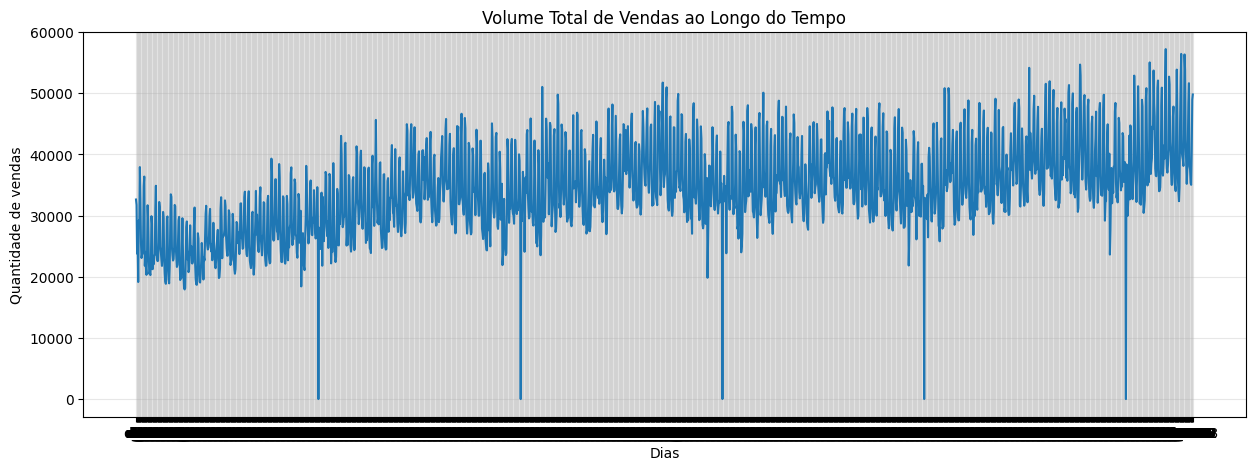

In [43]:
daily_sales = sales_by_day.sum(axis=0)

plt.figure(figsize=(15, 5))

plt.plot(daily_sales)

plt.title("Volume Total de Vendas ao Longo do Tempo")
plt.xlabel("Dias")
plt.ylabel("Quantidade de vendas")

plt.grid(alpha=0.3)

plt.show()

### Resultado

O volume total de vendas apresenta oscilações ao longo de todo o período analisado. Observa-se um leve crescimento na quantidade de vendas ao longo do tempo, acompanhado por quedas bruscas que parecem ocorrer em intervalos recorrentes.

### Interpretação

O comportamento indica que a demanda não é constante. Além da tendência de crescimento, existem padrões de variação que sugerem influência de fatores temporais, como dias da semana, eventos especiais, feriados ou sazonalidade.

### Insight para a Modelagem

As quedas recorrentes merecem investigação, pois podem representar padrões sistemáticos do negócio. A incorporação de informações do calendário, como datas, eventos e períodos festivos, pode contribuir para melhorar a capacidade preditiva dos modelos de previsão de demanda.

## Objetivo

Os eventos registrados no calendário estão associados a alterações no volume de vendas?

### Hipótese

Espera-se que datas com eventos especiais apresentem comportamento de vendas diferente dos dias comuns.

### Preparação dos Dados

O dataset `calendar` contém informações sobre cada dia do período analisado, incluindo eventos, feriados e outras características temporais.

Inicialmente, será realizada uma inspeção das principais colunas para identificar quais atributos poderão ser utilizados nas análises seguintes.

In [44]:
# Visualiza as primeiras linhas do calendário
calendar.head()

# Exibe informações gerais do dataset
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


### Resultado

A inspeção inicial do dataset `calendar` mostrou que ele contém informações temporais e eventos associados a cada dia do período analisado.

### Interpretação

Foram identificadas colunas referentes à data (`date`), componentes temporais (`weekday`, `wday`, `month`, `year`) e eventos (`event_name_1`, `event_type_1`, `event_name_2` e `event_type_2`).

Essas informações serão importantes para investigar padrões temporais e verificar se eventos específicos influenciam o comportamento das vendas.

### Insight para a Modelagem

O dataset `calendar` será utilizado para enriquecer os dados de vendas por meio de um `merge`, permitindo incorporar variáveis temporais e relacionadas a eventos à base de modelagem.

## Objetivo

Qual é a quantidade de dias com e sem eventos registrados no calendário?

### Hipótese

Espera-se que a maior parte dos dias não possua eventos registrados, enquanto uma parcela menor corresponda a feriados, datas comemorativas ou outras ocasiões especiais.

### Preparação dos Dados

Será analisada a coluna `event_name_1`, responsável por registrar o principal evento associado a cada dia. Valores ausentes indicam que não houve evento registrado naquele dia.

In [45]:
days_with_and_without_events = calendar["event_name_1"].isna().value_counts()

days_with_and_without_events

event_name_1
True     1807
False     162
Name: count, dtype: int64

### Resultado

Foram identificados 1.807 dias sem eventos registrados e 162 dias com pelo menos um evento principal no calendário.

### Interpretação

A maior parte do período analisado não possui evento principal registrado em `event_name_1`. Apenas uma pequena parcela dos dias apresenta esse tipo de registro.

### Insight para a Modelagem

Embora pouco frequentes, eventos podem alterar significativamente o comportamento da demanda. Dessa forma, essa informação poderá ser incorporada como variável explicativa durante a etapa de modelagem.

Será analisada a coluna `event_type_1`, que classifica o tipo do principal evento registrado em cada dia. A distribuição dessas categorias ajudará a entender a diversidade de eventos presentes no calendário.

In [46]:
event_types = calendar["event_type_1"].value_counts(dropna=False)

event_types

event_type_1
NaN          1807
Religious      55
National       52
Cultural       37
Sporting       18
Name: count, dtype: int64

### Resultado

Foram identificadas quatro categorias de eventos principais no calendário:

- Religious: 55 dias
- National: 52 dias
- Cultural: 37 dias
- Sporting: 18 dias

Além disso, 1.807 dias não possuem nenhum evento registrado.

### Interpretação

Os eventos registrados concentram-se em poucas categorias, sendo os eventos religiosos e nacionais os mais frequentes. Entretanto, a maior parte do período analisado corresponde a dias sem qualquer evento, reforçando que essas ocorrências são relativamente raras.


### Insight para a Modelagem

As categorias de eventos poderão ser utilizadas como variáveis categóricas durante a modelagem. Mesmo ocorrendo em poucos dias, esses eventos podem provocar alterações relevantes na demanda de determinados produtos, especialmente em datas comemorativas ou grandes eventos nacionais.

## Objetivo

Existe algum padrão semanal no volume total de vendas?

### Hipótese

Espera-se que determinados dias da semana apresentem maior volume de vendas em função do comportamento dos consumidores e de hábitos de compra recorrentes.

### Preparação dos Dados

Serão utilizadas as vendas totais por dia, agregadas anteriormente, e a coluna `weekday` do dataset `calendar`. Os dados serão relacionados por meio da coluna `d`, permitindo calcular a média de vendas para cada dia da semana.

In [47]:
# Converte a série de vendas diárias em um DataFrame
daily_sales = sales_by_day.sum(axis=0).reset_index()

# Renomeia as colunas para facilitar a leitura
daily_sales.columns = ["d", "total_sales"]

# Relaciona as vendas diárias com o dia da semana
daily_sales = daily_sales.merge(calendar[["d", "weekday"]], on="d", how="left")

# Calcula a média de vendas para cada dia da semana
sales_by_weekday = (
    daily_sales.groupby("weekday")["total_sales"].mean().sort_values(ascending=False)
)

# Exibe o resultado
sales_by_weekday

weekday
Saturday     41546.894161
Sunday       41130.021898
Friday       34225.985348
Monday       32852.967033
Tuesday      30368.780220
Thursday     30205.007326
Wednesday    30010.021978
Name: total_sales, dtype: float64

### Resultado

A análise da média do volume total de vendas por dia da semana mostrou que **sábado** apresentou a maior média de vendas (41.546,89), seguido por **domingo** (41.130,02). Em contrapartida, **quarta-feira** registrou a menor média (30.010,02), seguida por **quinta-feira** (30.205,01).

### Interpretação

Os resultados indicam um padrão semanal no comportamento da demanda. Observa-se um aumento significativo nas vendas durante o fim de semana, enquanto os dias úteis apresentam volumes médios inferiores. Esse comportamento pode estar relacionado aos hábitos de compra dos consumidores, que tendem a concentrar suas compras aos sábados e domingos.

### Insight para a Modelagem

O dia da semana demonstra forte potencial como variável explicativa para a previsão de demanda. A inclusão dessa informação no modelo poderá contribuir para capturar padrões sazonais de curto prazo e melhorar a precisão das previsões.

## Objetivo

Os eventos registrados no calendário influenciam o volume total de vendas?

### Hipótese

Espera-se que dias com eventos apresentem comportamento de vendas diferente dos dias sem eventos, em função de datas comemorativas, feriados e outras ocasiões especiais.

### Preparação dos Dados

Será criada uma variável indicando se cada dia possui ou não um evento principal registrado. Em seguida, essa informação será relacionada ao volume total de vendas diárias para comparar a média de vendas entre os dois grupos.

In [48]:
# Cria uma coluna indicando se o dia possui evento
calendar["has_event"] = calendar["event_name_1"].notna()

# Relaciona as vendas diárias ao calendário
daily_sales_event = daily_sales.merge(calendar[["d", "has_event"]], on="d", how="left")

# Calcula a média de vendas por presença de evento
sales_by_event = daily_sales_event.groupby("has_event")["total_sales"].mean()

# Exibe o resultado
sales_by_event

has_event
False    34489.207504
True     32655.149351
Name: total_sales, dtype: float64

### Resultado

A média de vendas em dias sem eventos foi de 34.489,21 unidades, enquanto nos dias com eventos registrados foi de 32.655,15 unidades.

### Interpretação

Ao contrário da hipótese inicial, os dias com eventos apresentaram uma média de vendas inferior aos dias sem eventos. Isso indica que a simples presença de um evento não implica, necessariamente, aumento da demanda.

Esse comportamento pode estar relacionado ao tipo de evento, à sua relevância para os consumidores ou ao fato de diferentes categorias de eventos exercerem impactos distintos sobre as vendas.

### Insight para a Modelagem

A presença de um evento, isoladamente, pode não ser suficiente para explicar o comportamento das vendas. Nas próximas etapas, será importante investigar o efeito de cada categoria de evento individualmente (`Religious`, `National`, `Cultural` e `Sporting`), em vez de considerar apenas uma variável binária indicando a existência de evento.



## Objetivo

Os diferentes tipos de eventos apresentam comportamentos distintos no volume médio de vendas?

### Hipótese

Espera-se que determinados tipos de eventos influenciem as vendas de maneira diferente, resultando em médias de vendas distintas entre as categorias.

### Preparação dos Dados

Serão relacionadas as vendas diárias ao tipo do evento principal (`event_type_1`). Em seguida, será calculada a média de vendas para cada categoria de evento, permitindo comparar seus possíveis impactos na demanda.

In [49]:
# Relaciona as vendas diárias ao tipo de evento
daily_sales_event_type = daily_sales.merge(
    calendar[["d", "event_type_1"]], on="d", how="left"
)

# Calcula a média de vendas por tipo de evento
sales_by_event_type = (
    daily_sales_event_type.groupby("event_type_1")["total_sales"]
    .mean()
    .sort_values(ascending=False)
)

# Exibe o resultado
sales_by_event_type

event_type_1
Sporting     35796.062500
Cultural     34234.742857
Religious    33760.692308
National     29458.509804
Name: total_sales, dtype: float64

### Resultado

A média de vendas variou entre os diferentes tipos de eventos. Eventos esportivos apresentaram a maior média de vendas (35.796,06), seguidos por eventos culturais (34.234,74) e religiosos (33.760,69). Os eventos nacionais registraram a menor média (29.458,51).

### Interpretação

Os resultados indicam que nem todos os tipos de eventos exercem o mesmo impacto sobre a demanda. Enquanto eventos esportivos e culturais estão associados a maiores volumes médios de vendas, eventos nacionais apresentaram médias inferiores às demais categorias.

Entretanto, essa análise é descritiva e não permite concluir que o tipo de evento seja a causa direta dessas diferenças, sendo necessária uma investigação mais aprofundada considerando outros fatores temporais.

### Insight para a Modelagem

Os diferentes tipos de eventos demonstram comportamentos distintos em relação ao volume de vendas, indicando que `event_type_1` possui potencial para ser utilizada como variável explicativa na previsão de demanda. Modelos de Machine Learning poderão aprender esses padrões e avaliar sua real contribuição para a qualidade das previsões.

## Objetivo

Existe variação no volume médio de vendas entre os meses do ano?

### Hipótese

Espera-se que alguns meses apresentem maior volume médio de vendas em função da sazonalidade, períodos festivos e comportamento dos consumidores.

### Preparação dos Dados

As vendas diárias serão relacionadas ao mês correspondente por meio da coluna `month` do dataset `calendar`. Em seguida, será calculada a média de vendas para cada mês, permitindo identificar possíveis padrões sazonais.

In [50]:
# Relaciona as vendas diárias ao mês correspondente
daily_sales_month = daily_sales.merge(calendar[["d", "month"]], on="d", how="left")

# Calcula a média de vendas por mês
sales_by_month = daily_sales_month.groupby("month")["total_sales"].mean()


sales_by_month

month
1     33832.348101
2     34644.641176
3     34339.838710
4     34258.683908
5     32503.851613
6     35001.413333
7     35122.419355
8     35946.645161
9     35479.260000
10    34713.477419
11    33290.826667
12    32980.464516
Name: total_sales, dtype: float64

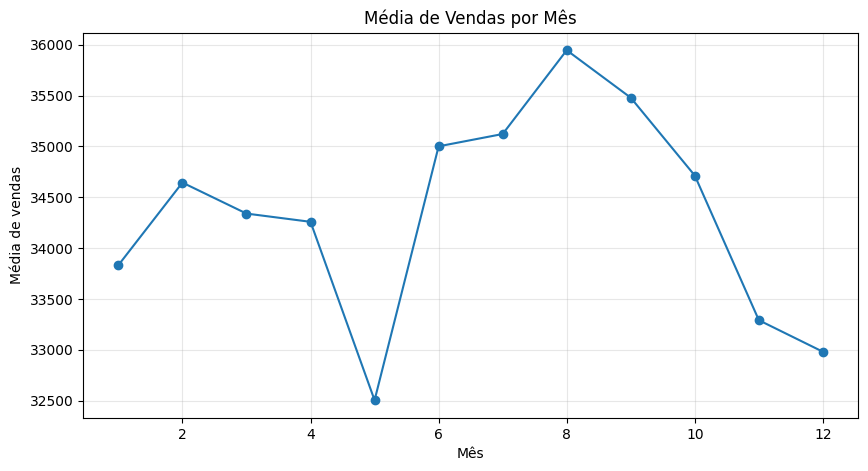

In [51]:
plt.figure(figsize=(10, 5))

plt.plot(sales_by_month.index, sales_by_month.values, marker="o")

plt.title("Média de Vendas por Mês")
plt.xlabel("Mês")
plt.ylabel("Média de vendas")

plt.grid(alpha=0.3)

plt.show()

### Resultado

A média de vendas apresentou variações ao longo dos meses. O maior volume médio foi observado no mês **8** (35.946,65), seguido pelos meses **9** (35.479,26) e **7** (35.122,42). O menor volume médio ocorreu no mês **5** (32.503,85), enquanto os meses **11** e **12** também apresentaram médias inferiores aos demais.

### Interpretação

Observa-se uma sazonalidade moderada nas vendas. Após uma redução no mês 5, ocorre um crescimento contínuo entre os meses 6 e 8, seguido por uma queda gradual até o final do período anual. Esse comportamento sugere que fatores sazonais podem influenciar a demanda, embora a variação entre os meses não seja extremamente elevada.

### Insight para a Modelagem

A variável `month` apresenta potencial para capturar padrões sazonais da demanda e deve ser considerada como uma variável explicativa na construção dos modelos de previsão. Além disso, pode ser interessante avaliar interações entre o mês e outras variáveis temporais, como eventos especiais e dia da semana.

## Objetivo

Existem diferenças no volume total de vendas entre os estados analisados?

### Hipótese

Espera-se que os estados apresentem comportamentos distintos de vendas devido a diferenças populacionais, econômicas e de consumo.

### Preparação dos Dados

Será calculado o volume total de vendas por estado utilizando a coluna `state_id` do dataset `sales`. Em seguida, os resultados serão comparados para identificar possíveis diferenças entre as regiões.

In [52]:
sales_by_state = (
    sales.assign(total_sales=product_total_sales)
    .groupby("state_id")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)


sales_by_state

state_id
CA    28675547
TX    18899006
WI    18120856
Name: total_sales, dtype: int64

### Resultado

A Califórnia (CA) registrou o maior volume total de vendas (**28,68 milhões** de unidades), seguida por Texas (TX), com **18,90 milhões**, e Wisconsin (WI), com **18,12 milhões**.

### Interpretação

A Califórnia concentra o maior volume de vendas entre os estados analisados. Texas e Wisconsin apresentam volumes semelhantes, indicando um comportamento de demanda mais próximo entre essas duas regiões.

### Insight para a Modelagem

A variável `state_id` deve ser mantida na modelagem, pois os estados apresentam diferenças relevantes no volume de demanda. As variáveis `snap_CA`, `snap_TX` e `snap_WI` serão avaliadas separadamente na análise de SNAP.


## Objetivo

A quantidade de lojas é semelhante entre os estados analisados?

### Hipótese

Espera-se que os estados possuam quantidades diferentes de lojas, o que pode influenciar diretamente o volume total de vendas observado.

### Preparação dos Dados

Será utilizada a combinação das colunas `state_id` e `store_id` para contabilizar o número de lojas existentes em cada estado.

In [53]:
# Conta a quantidade de lojas por estado
stores_by_state = (
    sales.groupby("state_id")["store_id"].nunique().sort_values(ascending=False)
)

stores_by_state

state_id
CA    4
TX    3
WI    3
Name: store_id, dtype: int64

## Objetivo

Como o volume total de vendas está distribuído entre as categorias de produtos?

### Hipótese

Espera-se que algumas categorias concentrem maior volume de vendas.

### Preparação dos Dados

Será calculado o volume total de vendas por categoria (`cat_id`).

In [54]:
# Total de vendas por categoria
sales_by_category = (
    sales.assign(total_sales=product_total_sales)
    .groupby("cat_id")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_category

cat_id
FOODS        45089939
HOUSEHOLD    14480670
HOBBIES       6124800
Name: total_sales, dtype: int64

### Resultado

A categoria **FOODS** concentrou **68,6%** do volume total de vendas (45.089.939 unidades), seguida por **HOUSEHOLD**, com **22,0%** (14.480.670), e **HOBBIES**, com **9,3%** (6.124.800).

### Interpretação

O volume de vendas está fortemente concentrado na categoria **FOODS**, que representa mais de dois terços das vendas do período. As categorias **HOUSEHOLD** e **HOBBIES** possuem participação significativamente menor.

### Insight para a Modelagem

A variável `cat_id` deve ser mantida na modelagem, pois as categorias apresentam diferenças relevantes no volume de demanda.

## Objetivo

Avaliar como o volume total de vendas está distribuído entre os departamentos.

### Hipótese

Espera-se que alguns departamentos concentrem uma parcela maior da demanda.

### Preparação dos Dados

Será calculado o volume total de vendas por departamento (`dept_id`).

In [55]:
# Total de vendas por departamento
sales_by_department = (
    sales.assign(total_sales=product_total_sales)
    .groupby("dept_id")["total_sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_department

dept_id
FOODS_3        32372076
HOUSEHOLD_1    11500526
FOODS_2         7629822
HOBBIES_1       5596460
FOODS_1         5088041
HOUSEHOLD_2     2980144
HOBBIES_2        528340
Name: total_sales, dtype: int64

### Resultado

O departamento `FOODS_3` apresentou o maior volume de vendas, com **32,37 milhões** de unidades, seguido por `HOUSEHOLD_1`, com **11,50 milhões**, e `FOODS_2`, com **7,63 milhões**.

### Interpretação

A demanda apresenta forte concentração em `FOODS_3`, que representa aproximadamente **49,3%** das vendas entre os departamentos analisados. Os demais departamentos apresentam volumes significativamente menores.

### Insight para a Modelagem

A variável `dept_id` deve ser mantida na modelagem, pois apresenta diferenças relevantes de volume e permite capturar padrões de demanda em uma granularidade maior que `cat_id`.

## Objetivo

Avaliar se a ativação do programa SNAP está associada a diferenças no volume médio de vendas.

### Hipótese

Espera-se que os dias com SNAP apresentem comportamento de vendas diferente dos dias sem SNAP.

### Preparação dos Dados

As vendas diárias serão relacionadas às variáveis `snap_CA`, `snap_TX` e `snap_WI` do calendário para comparar o volume médio de vendas em dias com e sem SNAP.

In [56]:
# Relaciona vendas diárias às informações de SNAP
daily_sales_snap = daily_sales.merge(
    calendar[["d", "snap_CA", "snap_TX", "snap_WI"]],
    on="d",
    how="left"
)

# Calcula a média de vendas para dias com e sem SNAP
sales_by_snap = {
    "CA": daily_sales_snap.groupby("snap_CA")["total_sales"].mean(),
    "TX": daily_sales_snap.groupby("snap_TX")["total_sales"].mean(),
    "WI": daily_sales_snap.groupby("snap_WI")["total_sales"].mean()
}


sales_by_snap

{'CA': snap_CA
 0    33408.506625
 1    36241.738095
 Name: total_sales, dtype: float64,
 'TX': snap_TX
 0    33263.012471
 1    36538.038095
 Name: total_sales, dtype: float64,
 'WI': snap_WI
 0    33239.736555
 1    36585.439683
 Name: total_sales, dtype: float64}

In [57]:
# Vendas diárias por estado
sales_columns = sales.filter(regex="^d_").columns

sales_by_state_day = (
    sales.groupby("state_id")[sales_columns]
    .sum()
    .T
)

sales_by_state_day.index.name = "d"

sales_by_state_day = sales_by_state_day.reset_index()

sales_by_state_day.head()

state_id,d,CA,TX,WI
0,d_1,14195,9438,8998
1,d_2,13805,9630,8314
2,d_3,10108,6778,6897
3,d_4,11047,7381,6984
4,d_5,9925,5912,3309


In [58]:
# Relaciona vendas estaduais ao calendário
sales_by_state_day = sales_by_state_day.merge(
    calendar[["d", "snap_CA", "snap_TX", "snap_WI"]],
    on="d",
    how="left"
)

sales_by_state_day.head()

,d,CA,TX,WI,snap_CA,snap_TX,snap_WI
0,d_1,14195,9438,8998,0,0,0
1,d_2,13805,9630,8314,0,0,0
2,d_3,10108,6778,6897,0,0,0
3,d_4,11047,7381,6984,1,1,0
4,d_5,9925,5912,3309,1,0,1


In [59]:
# Média de vendas por estado em dias com e sem SNAP
sales_by_snap_state = {
    "CA": sales_by_state_day.groupby("snap_CA")["CA"].mean(),
    "TX": sales_by_state_day.groupby("snap_TX")["TX"].mean(),
    "WI": sales_by_state_day.groupby("snap_WI")["WI"].mean()
}

sales_by_snap_state

{'CA': snap_CA
 0    14605.813718
 1    15771.885714
 Name: CA, dtype: float64,
 'TX': snap_TX
 0     9519.082619
 1    10612.734921
 Name: TX, dtype: float64,
 'WI': snap_WI
 0     8838.505066
 1    10763.577778
 Name: WI, dtype: float64}

### Resultado

As vendas médias foram maiores nos dias com SNAP nos três estados. A diferença foi de **8,0%** na Califórnia, **11,5%** no Texas e **21,8%** em Wisconsin.

### Interpretação

A ativação do SNAP está associada a maiores volumes médios de vendas nos três estados, com a maior diferença observada em Wisconsin.

### Insight para a Modelagem

As variáveis `snap_CA`, `snap_TX` e `snap_WI` devem ser mantidas como potenciais variáveis explicativas, pois apresentam associação com o volume de vendas dentro de seus respectivos estados.

## Objetivo

Avaliar a relação entre preço de venda e volume de demanda.

### Hipótese

Espera-se que produtos com preços mais elevados apresentem, em média, menor volume de vendas.

### Preparação dos Dados

As vendas serão agregadas por produto, loja e semana para serem relacionadas aos preços do dataset `sell_prices`.

In [60]:
# Seleciona as colunas de vendas diárias
sales_columns = sales.filter(regex="^d_").columns

# Relaciona os dias às respectivas semanas
sales_week = sales[["item_id", "store_id"] + list(sales_columns)].melt(
    id_vars=["item_id", "store_id"],
    var_name="d",
    value_name="sales"
)

sales_week = sales_week.merge(
    calendar[["d", "wm_yr_wk"]],
    on="d",
    how="left"
)

sales_week.head()

,item_id,store_id,d,sales,wm_yr_wk
0,HOBBIES_1_001,CA_1,d_1,0,11101
1,HOBBIES_1_002,CA_1,d_1,0,11101
2,HOBBIES_1_003,CA_1,d_1,0,11101
3,HOBBIES_1_004,CA_1,d_1,0,11101
4,HOBBIES_1_005,CA_1,d_1,0,11101


In [61]:
# Agrega as vendas por produto, loja e semana
weekly_sales = (
    sales_week
    .groupby(["item_id", "store_id", "wm_yr_wk"])["sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,item_id,store_id,wm_yr_wk,sales
0,FOODS_1_001,CA_1,11101,10
1,FOODS_1_001,CA_1,11102,6
2,FOODS_1_001,CA_1,11103,10
3,FOODS_1_001,CA_1,11104,13
4,FOODS_1_001,CA_1,11105,15


In [62]:
# Relaciona vendas semanais aos preços
sales_prices = weekly_sales.merge(
    prices[["item_id", "store_id", "wm_yr_wk", "sell_price"]],
    on=["item_id", "store_id", "wm_yr_wk"],
    how="left"
)

sales_prices.head()

,item_id,store_id,wm_yr_wk,sales,sell_price
0,FOODS_1_001,CA_1,11101,10,2.0
1,FOODS_1_001,CA_1,11102,6,2.0
2,FOODS_1_001,CA_1,11103,10,2.0
3,FOODS_1_001,CA_1,11104,13,2.0
4,FOODS_1_001,CA_1,11105,15,2.0


In [63]:
# Verifica e trata preços ausentes
missing_prices = sales_prices["sell_price"].isna().sum()
missing_percentage = sales_prices["sell_price"].isna().mean() * 100

# Remove registros sem preço
sales_prices_valid = sales_prices.dropna(subset=["sell_price"]).copy()

# Verifica o tamanho da base após o filtro
sales_prices_valid.shape

(6597201, 5)

In [64]:
# Correlação entre preço e vendas
price_sales_corr = (
    sales_prices_valid["sell_price"]
    .corr(sales_prices_valid["sales"])
)

price_sales_corr

# Cria faixas de preço
sales_prices_valid["price_group"] = pd.qcut(
    sales_prices_valid["sell_price"],
    q=4,
    labels=["Baixo", "Médio-baixo", "Médio-alto", "Alto"]
)

# Média de vendas por faixa de preço
sales_by_price_group = (
    sales_prices_valid
    .groupby("price_group", observed=True)["sales"]
    .mean()
)

sales_by_price_group

price_group
Baixo          20.221357
Médio-baixo     8.839455
Médio-alto      6.141631
Alto            4.295751
Name: sales, dtype: float64

### Resultado

A correlação entre preço e vendas foi de **-0,173**, indicando uma relação linear negativa fraca. A análise por faixas de preço apresentou um padrão mais evidente: a média de vendas foi de **20,22 unidades** na faixa de menor preço e caiu para **4,30 unidades** na faixa de maior preço.

### Interpretação

Os resultados indicam associação entre preços mais elevados e menor volume médio de vendas. A análise por faixas reforça essa associação, com menor volume médio nas faixas de preço mais elevadas.

### Insight para a Modelagem

A variável `sell_price` deve ser mantida como potencial variável explicativa. Sua contribuição para a previsão deverá ser avaliada em conjunto com as demais variáveis da demanda.

## Objetivo

Avaliar a distribuição do volume de vendas entre as lojas.

### Hipótese

Espera-se que existam diferenças relevantes no volume de demanda entre as lojas.

In [65]:
# Total de vendas por loja
sales_by_store = (
    sales.assign(total_sales=product_total_sales)
         .groupby("store_id")["total_sales"]
         .sum()
         .sort_values(ascending=False)
)

sales_by_store

store_id
CA_3    11188180
CA_1     7698216
TX_2     7214384
WI_2     6544012
WI_3     6427782
TX_3     6089330
CA_2     5685475
TX_1     5595292
WI_1     5149062
CA_4     4103676
Name: total_sales, dtype: int64

### Resultado

A loja `CA_3` apresentou o maior volume total de vendas, com **11,19 milhões** de unidades, enquanto `CA_4` apresentou o menor, com **4,10 milhões**.

### Interpretação

O volume de vendas varia significativamente entre as lojas. A diferença entre a maior e a menor loja é de aproximadamente **2,7 vezes**, indicando padrões distintos de demanda mesmo dentro dos mesmos estados.

### Insight para a Modelagem

A variável `store_id` deve ser mantida na modelagem, pois apresenta diferenças relevantes no volume de demanda entre as lojas.

## Objetivo

Verificar a consistência dos valores de vendas utilizados na análise.

### Hipótese

Espera-se que não existam valores negativos e que os valores ausentes sejam inexistentes ou previamente tratados.

In [66]:
# Verifica valores nulos e negativos nas vendas
print("Valores nulos:", sales_by_day.isna().sum().sum())
print("Valores negativos:", (sales_by_day < 0).sum().sum())

Valores nulos: 0
Valores negativos: 0


# Conclusão da EDA

A análise exploratória identificou os principais fatores associados ao comportamento da demanda:

- **Tempo:** foram observadas oscilações ao longo do período e diferenças relevantes entre os dias da semana e meses.
- **Produtos:** a demanda apresenta forte concentração, com poucos produtos respondendo por grande parte das vendas.
- **Categorias e departamentos:** `FOODS` concentra a maior parcela das vendas, com destaque para `FOODS_3`.
- **Lojas e estados:** existem diferenças relevantes de demanda entre lojas e estados.
- **Eventos e SNAP:** eventos e dias com SNAP apresentaram diferenças no volume médio de vendas.
- **Preço:** foi observada associação negativa entre preço e volume vendido, com redução da média de vendas nas faixas de preço mais elevadas.

### Direcionamento para a Modelagem

As variáveis temporais, de produto, loja, estado, categoria, departamento, eventos, SNAP e preço serão consideradas na construção da base de modelagem. A relevância de cada variável será avaliada durante o desenvolvimento dos modelos.

A etapa seguinte será a preparação da base para modelagem, incluindo a definição da variável-alvo, criação das variáveis temporais e demais features necessárias ao modelo de previsão.